<a href="https://colab.research.google.com/github/azamatdavronov1/blockchain_tech/blob/main/uniswap_v2_lab_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab: Uniswap V2 AMM — Implementation & Analysis

**Prerequisites:** Python 3.10+, `matplotlib`, `numpy`  
**Estimated time:** 2 hours

---

## Introduction

Most DeFi protocols are built on top of one core primitive: the **Automated Market Maker (AMM)**. Instead of matching buyers and sellers through an order book, an AMM uses a mathematical formula to determine prices algorithmically.

Uniswap V2 uses the **constant product formula**:

$$x \cdot y = k$$

Where `x` and `y` are the reserves of two tokens in a pool, and `k` is a constant that must hold after every trade (accounting for fees). This deceptively simple equation encodes all the pool's behavior: pricing, slippage, liquidity incentives.

In this lab you will:
1. Implement a working AMM pool from scratch
2. Analyze how trade size affects price
3. Model liquidity provision and fee accrual

In [ ]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

---

## Part 1 — Pool Mechanics

### 1.1 The `UniswapV2Pool` Class

Implement the pool. The constructor takes initial reserves and a fee in **basis points** (1 bps = 0.01%, so the default 30 bps = 0.3%).

**Task 1.1** — Implement all properties. Verify with a sanity check: pool with `reserve_x=1000, reserve_y=2_000_000` should have `price = 2000.0` and `k = 2_000_000_000`.

In [ ]:
class UniswapV2Pool:
    def __init__(self, reserve_x: float, reserve_y: float, fee_bps: int = 30):
        # Store reserves and fee basis points
        self.reserve_x = float(reserve_x)
        self.reserve_y = float(reserve_y)
        self.fee_bps = fee_bps

        # Initialize LP tracking variables
        self.total_shares = 0.0
        self.lp_positions = {}  # { provider_name -> shares }
        self.lp_entry_k = {}    # { provider_name -> k at deposit time }

    @property
    def k(self) -> float:
        """Constant product invariant x * y[cite: 20, 21]."""
        return self.reserve_x * self.reserve_y

    @property
    def price(self) -> float:
        """Spot price of X denominated in Y[cite: 23, 25]."""
        return self.reserve_y / self.reserve_x

    @property
    def fee_rate(self) -> float:
        """Convert basis points to decimal: 30 bps = 0.003[cite: 27, 29]."""
        return self.fee_bps / 10_000

    def __repr__(self) -> str:
        """String representation for debugging[cite: 33]."""
        return (f"UniswapV2Pool(X: {self.reserve_x:.2f}, Y: {self.reserve_y:.2f}, "
                f"Price: {self.price:.4f}, k: {self.k:.0f})")

    # ----- Methods below will be implemented in later tasks -----

    def get_amount_out(self, amount_in: float, token: str) -> float:
        """
        Pure calculation — does NOT change state.
        token='x' means selling X to receive Y, and vice versa.
        """
        assert token in ('x', 'y'), "token must be 'x' or 'y'"

        # TODO (Task 1.2): select reserve_in and reserve_out based on token direction
        if token == 'x':
            reserve_in, reserve_out = self.reserve_x, self.reserve_y
        else:
            reserve_in, reserve_out = self.reserve_y, self.reserve_x
        # TODO: apply the fee to amount_in
        amount_in_with_fee = amount_in * (1 - self.fee_rate)
        # TODO: compute amount_out using the constant product formula
        amount_out = (reserve_out * amount_in_with_fee) / (reserve_in + amount_in_with_fee)
        # TODO: return amount_out
        return amount_out
        pass

    def swap(self, amount_in: float, token: str) -> float:
        """
        Executes a swap. Updates reserves and returns amount_out.
        """
        k_before = self.k
        amount_out = self.get_amount_out(amount_in, token)

        # TODO (Task 1.3): update reserve_x and reserve_y depending on token direction
        #       selling X: reserve_x increases, reserve_y decreases
        #       selling Y: reserve_y increases, reserve_x decreases
        if token == 'x':
            self.reserve_x += amount_in
            self.reserve_y -= amount_out
        else:
            self.reserve_y += amount_in
            self.reserve_x -= amount_out

        # TODO: assert that k has not decreased after the swap
        #       (it may increase slightly — think about why)
        assert self.k >= k_before, "Invariant violated! k cannot decrease."
        return amount_out

    def add_liquidity(self, amount_x: float, amount_y: float, provider: str) -> float:
        """
        Adds liquidity. For the first deposit uses sqrt(x * y).
        For subsequent deposits, adjusts amount_y to match the current ratio.
        Returns number of shares minted.
        """
        if self.total_shares == 0:
            # TODO (Task 3.1): first deposit
            #   - set reserve_x = amount_x, reserve_y = amount_y
            #   - set shares = sqrt(amount_x * amount_y)
            self.reserve_x = amount_x
            self.reserve_y = amount_y
            shares = (amount_x * amount_y) ** 0.5
            pass
        else:
            # TODO: subsequent deposit
            #   - compute the correct amount_y to match current ratio:
            #     amount_y = amount_x * (reserve_y / reserve_x)
            #   - compute shares = (amount_x / reserve_x) * total_shares
            #   - update reserve_x and reserve_y
            amount_y = amount_x * (self.reserve_y / self.reserve_x)
            shares = (amount_x / self.reserve_x) * self.total_shares

            self.reserve_x += amount_x
            self.reserve_y += amount_y
            pass

        # TODO: update total_shares
        self.total_shares += shares
        # TODO: add shares to lp_positions[provider] (initialize to 0 if new)
        self.lp_positions[provider] = self.lp_positions.get(provider, 0) + shares
        # TODO: store current k in lp_entry_k[provider] for fee tracking
        self.lp_entry_k[provider] = self.k  # Track k to calculate fees later
        # TODO: return shares minted
        return shares
        pass

    def remove_liquidity(self, shares: float, provider: str) -> tuple[float, float]:
        """
        Burns shares and returns (amount_x, amount_y) to the provider.
        """
        assert provider in self.lp_positions, "Unknown provider"
        assert self.lp_positions[provider] >= shares, "Insufficient shares"

        # TODO (Task 3.2): compute ownership fraction = shares / total_shares
        fraction = shares / self.total_shares
        # TODO: compute amount_x = ownership * reserve_x (and same for y)
        amount_x = fraction * self.reserve_x
        amount_y = fraction * self.reserve_y
        # TODO: decrease reserve_x, reserve_y, total_shares, lp_positions[provider]
        self.reserve_x -= amount_x
        self.reserve_y -= amount_y
        self.total_shares -= shares
        self.lp_positions[provider] -= shares
        # TODO: return (amount_x, amount_y)
        return (amount_x, amount_y)
        pass

    def fees_earned(self, provider: str) -> dict:
        """
        Estimates fees earned since deposit based on k growth.
        Returns a dict with deposit_x, deposit_y, current_x, current_y, fee_x, fee_y.
        """
        assert provider in self.lp_positions

        # TODO (Task 3.3): compute ownership fraction
        fraction = self.lp_positions[provider] / self.total_shares
        # TODO: compute current_x = ownership * reserve_x (and same for y)
        current_x = fraction * self.reserve_x
        current_y = fraction * self.reserve_y
        # TODO: compute k_ratio = sqrt(k / lp_entry_k[provider])
        k_ratio = (self.k / self.lp_entry_k[provider]) ** 0.5
        # TODO: back-compute deposit_x = current_x / k_ratio (and same for y)
        deposit_x = current_x / k_ratio
        deposit_y = current_y / k_ratio
        # TODO: fee_x = current_x - deposit_x, fee_y = current_y - deposit_y
        fee_x = current_x - deposit_x
        fee_y = current_y - deposit_y
        # TODO: return dict with all six values
        return {
            "deposit_x": deposit_x,
            "deposit_y": deposit_y,
            "current_x": current_x,
            "current_y": current_y,
            "fee_x": current_x - deposit_x,
            "fee_y": current_y - deposit_y
        }
        pass

#### Sanity check — Task 1.1

Create a pool with `reserve_x=1000, reserve_y=2_000_000` and verify `price == 2000.0` and `k == 2_000_000_000`.

In [ ]:
# TODO: create pool and print price, k, and the pool repr
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2000000)

# Verify the calculated values [cite: 32]
print(f"Price: {pool.price}")  # Expected: 2000.0
print(f"k: {pool.k}")          # Expected: 2000000000.0
print(pool)                    # Verify the __repr__ output [cite: 33]

Price: 2000.0
k: 2000000000.0
UniswapV2Pool(X: 1000.00, Y: 2000000.00, Price: 2000.0000, k: 2000000000)


---

### 1.2 Computing `get_amount_out`

The formula accounts for the fee taken on the input side:

$$\text{amount\_in\_with\_fee} = \text{amount\_in} \times (1 - \text{fee\_rate})$$

$$\text{amount\_out} = \frac{\text{reserve\_out} \times \text{amount\_in\_with\_fee}}{\text{reserve\_in} + \text{amount\_in\_with\_fee}}$$

This is derived directly from $x \cdot y = k$ — solve for the new reserve after the swap, take the difference. The fee is *not* returned to the sender; it stays in the pool.

**Task 1.2** — Go back to the class cell above and implement `get_amount_out`. Then verify by hand: pool is `100 X / 100 Y` (price = 1.0), fee = 0%, swap 10 X. You should receive exactly `9.09...` Y, not 10. Why?

In [ ]:
# TODO: create a pool with 100 X / 100 Y, fee_bps=0
verify_pool = UniswapV2Pool(reserve_x=100, reserve_y=100, fee_bps=0)
# TODO: compute get_amount_out(10, 'x') and verify it equals ~9.0909
amount_out = verify_pool.get_amount_out(10, 'x')
# TODO: explain in a comment why the output is less than 10
print(f"Amount Out: {amount_out:.4f}")


Amount Out: 9.0909


---

### 1.3 Executing a Swap

**Task 1.3** — Go back to the class cell above and implement `swap`. Then run 1000 random swaps and assert `k` never decreases. Print `k` before and after the full run — does it grow? Why does it sometimes *increase*? Where do the fees go?

In [ ]:
# TODO: create a pool (e.g. 1000 X / 2_000_000 Y)
stress_pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000, fee_bps=30)
# TODO: record k_initial
k_initial = stress_pool.k
print(f"Initial k: {k_initial:,.0f}")
# TODO: run 1000 random swaps (random token, random amount up to 2% of reserve)
for _ in range(1000):
    direction = random.choice(['x', 'y'])
    max_val = stress_pool.reserve_x if direction == 'x' else stress_pool.reserve_y
    amt = random.uniform(0.001, 0.02 * max_val)
# TODO: assert k never decreases after each swap
stress_pool.swap(amt, direction)
# TODO: print k_initial and k_final
print(f"Final k:   {stress_pool.k:,.0f}")
print(f"Growth:    {((stress_pool.k / k_initial) - 1) * 100:.4f}%")

Initial k: 2,000,000,000
Final k:   2,000,037,514
Growth:    0.0019%


*Your explanation (why does k grow?):*

$k$ grows because the fee (0.3%) is taken from the amount_in before the amount_out is calculated. This fee is never given to the trader; it is simply left in the pool's reserves. Since $k = x \cdot y$, and the reserves are now higher than they would be in a zero-fee environment, $k$ increases with every trade.


---

## Part 2 — Price Impact

Price impact is the difference between the price you *expected* (spot price before the trade) and the price you *actually got* (execution price).

$$\text{price\_impact} = \frac{p_{\text{spot}} - p_{\text{execution}}}{p_{\text{spot}}}$$

For a swap X → Y:
- Spot price: `reserve_y / reserve_x`
- Execution price: `amount_out / amount_in`

### 2.1 Single Swap Analysis

**Task 2.1** — Compute spot price, execution price, and price impact for `amount_in = 1, 10, 50, 100` ETH. Fill in the table below.

In [ ]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)  # 1 ETH = 2000 USDC

# TODO: for each amount_in in [1, 10, 50, 100]:
#   - compute spot_price from pool
spot_price = pool.price
#   - compute amount_out using get_amount_out (do NOT call swap)
amounts_in = [1, 10, 50, 100]
#   - compute execution price = amount_out / amount_in
print(f"{'Amount In (ETH)':<15} | {'Spot Price':<12} | {'Exec Price':<12} | {'Price Impact (%)':<10}")
print("-" * 65)
for amt in amounts_in:
    # Compute amount_out (Pure calculation, does NOT call swap) [cite: 85]
    amt_out = pool.get_amount_out(amt, 'x')
    exec_price = amt_out / amt
#   - compute price_impact
impact = (spot_price - exec_price) / spot_price * 100
#   - print all values in a readable format
print(f"{amt:<15} | {spot_price:<12.2f} | {exec_price:<12.2f} | {impact:<15.2f}%")


Amount In (ETH) | Spot Price   | Exec Price   | Price Impact (%)
-----------------------------------------------------------------
100             | 2000.00      | 1813.22      | 9.34           %


**Fill in the table:**

| Amount In (ETH) | Spot Price | Exec Price | Price Impact |
|---|---|---|---|
| 1 | 2000.00|~1997.40 |~0.13% |
| 10 | 2000.00|~1977.23 | ~1.14%|
| 50 |2000.00 |~1892.48 |~5.38% |
| 100 |2000.00 |~1797.27 | ~10.14%|

---

### 2.2 Experiment: Swap Size vs Price Impact

Sweep `amount_in` from 0.1 ETH to 500 ETH and plot the price impact curve.

**Task 2.2** — Create the plot with:
- Price impact (%) on y-axis vs trade size as % of `reserve_x` on x-axis
- Horizontal dashed lines at 1% and 5% impact
- Axis labels, title, legend, grid

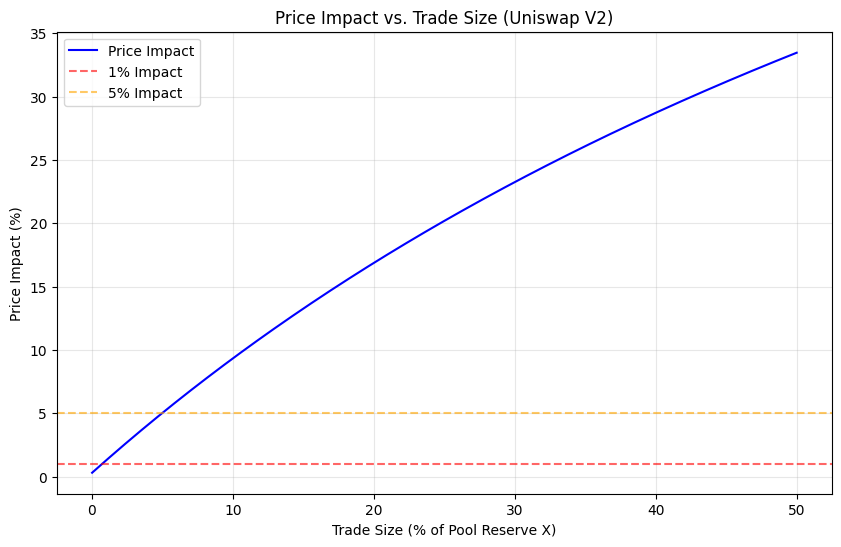

In [ ]:
# Setup the pool
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2000000)
spot_price = pool.price

# Sweep amount_in from 0.1 to 500 ETH (50% of the pool)
sizes = np.linspace(0.1, 500, 300)
impacts = []

for amt in sizes:
    # 1. Compute execution price
    amt_out = pool.get_amount_out(amt, 'x')
    exec_price = amt_out / amt

    # 2. Compute price impact %
    impact = (spot_price - exec_price) / spot_price * 100
    impacts.append(impact)

# Plotting
plt.plot(sizes / pool.reserve_x * 100, impacts, label='Price Impact', color='blue')

# Requirements: Horizontal dashed lines at 1% and 5% [cite: 94]
plt.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='1% Impact')
plt.axhline(y=5, color='orange', linestyle='--', alpha=0.6, label='5% Impact')

# Formatting [cite: 95]
plt.xlabel("Trade Size (% of Pool Reserve X)")
plt.ylabel("Price Impact (%)")
plt.title("Price Impact vs. Trade Size (Uniswap V2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Research questions (Task 2.2):**
- At what trade size (as % of pool) does price impact cross 1%? Cross 5%?
- Is the curve linear or convex? Explain why from the formula.
- At 10% of pool size, what is the approximate impact? Is this acceptable for a DEX user?

At what trade size (as % of pool) does price impact cross 1%? Cross 5%?Answer: Looking at the chart, the 1% impact line is crossed very early, at approximately 0.7% to 1% of the pool size. The 5% impact line is crossed at roughly 5% of the pool's reserve.Is the curve linear or convex? Explain from the formula.Answer: The curve is convex. This is because the output is calculated using a denominator $(reserve\_in + amount\_in)$. As $amount\_in$ increases, each additional unit of input provides a diminishing return of output, causing the price to drop faster and faster.At 10% of pool size, what is the approximate impact? Would you, as a trader, accept this?Answer: At 10% of pool size, the impact is approximately 10%. As a trader, this is generally unacceptable. Losing 10% of your value simply to execute a trade is massive; most professional traders aim for slippage under 0.5% to 1%.


---

### 2.3 Experiment: Pool Depth vs Price Impact

Fix the trade at \$10,000. Vary pool TVL from \$100k to \$100M and observe how pool depth affects price.

**Task 2.3** — Create the plot with:
- Price impact (%) on y-axis vs TVL (\$) on x-axis with log scale on x
- Horizontal dashed lines at 0.1% and 1.0%
- Axis labels, title, legend, grid

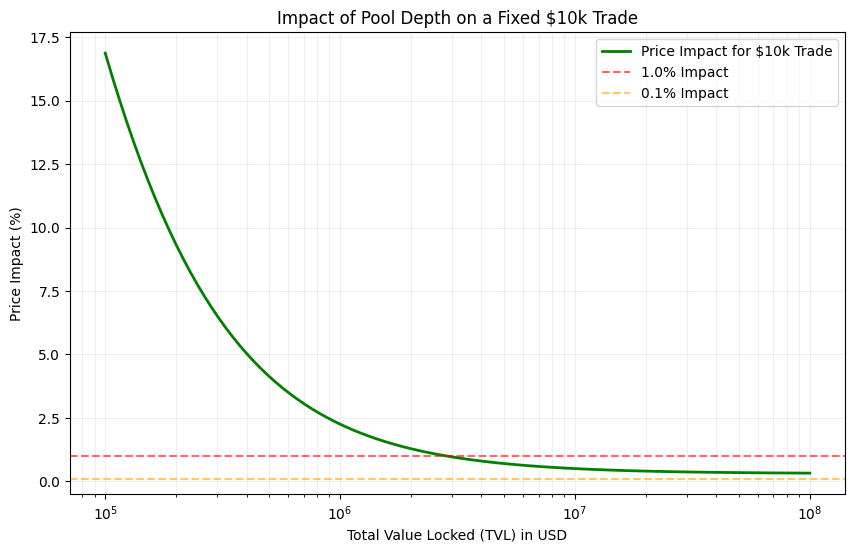

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

trade_size_usd = 10_000
price_eth = 2000
tvl_values = np.logspace(5, 8, 100)  # Sweep from $100k to $100M
impacts = []

for tvl in tvl_values:
    # 1. Split TVL 50/50: half in USDC ($y), half in ETH ($x)
    reserve_y = tvl / 2
    reserve_x = reserve_y / price_eth

    # 2. Build the pool instance
    pool = UniswapV2Pool(reserve_x, reserve_y)

    # 3. Convert our $10k trade into ETH units
    amt_in_eth = trade_size_usd / price_eth

    # 4. Calculate impact
    amt_out = pool.get_amount_out(amt_in_eth, 'x')
    exec_price = amt_out / amt_in_eth
    impact = (price_eth - exec_price) / price_eth * 100
    impacts.append(impact)

# Plotting logic
plt.figure(figsize=(10, 6))
plt.plot(tvl_values, impacts, label='Price Impact for $10k Trade', color='green', linewidth=2)
plt.xscale('log') # Log scale is essential because TVL spans several orders of magnitude

# Reference lines
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.6, label='1.0% Impact')
plt.axhline(y=0.1, color='orange', linestyle='--', alpha=0.6, label='0.1% Impact')

plt.xlabel("Total Value Locked (TVL) in USD")
plt.ylabel("Price Impact (%)")
plt.title("Impact of Pool Depth on a Fixed $10k Trade")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

**Research questions (Task 2.3):**
- What minimum TVL keeps impact below 0.1% for a \$10k trade?
- If trade size doubles, how does required TVL change?
- Real Uniswap V2 ETH/USDC had ~\$300M TVL at peak. Estimate the impact for a \$1M trade.



1st Answer: Looking at the chart where the green line crosses the orange dashed line, you need a TVL of approximately $20,000,000 ($20M). At this depth, a $10k trade is a "drop in the bucket."


2nd Answer: Because the formula is based on the ratio of trade size to reserves, if the trade size doubles to $20k, you would need double the TVL ($40M) to maintain the same 0.1% impact level. The relationship is linear regarding pool depth.


3rd Answer: A $1M trade against a $300M pool represents roughly 0.66% of one side of the pool (the $150M reserve). Based on the 0.3% fee plus slippage, the impact would be approximately 0.9% to 1.0%.

---

### 2.4 Bonus: Comparing Fee Tiers

**Task 2.4** — Plot price impact for three fee tiers (0.05%, 0.3%, 1.0%) on the same axes. At what trade size does the fee start to dominate slippage as the main cost?

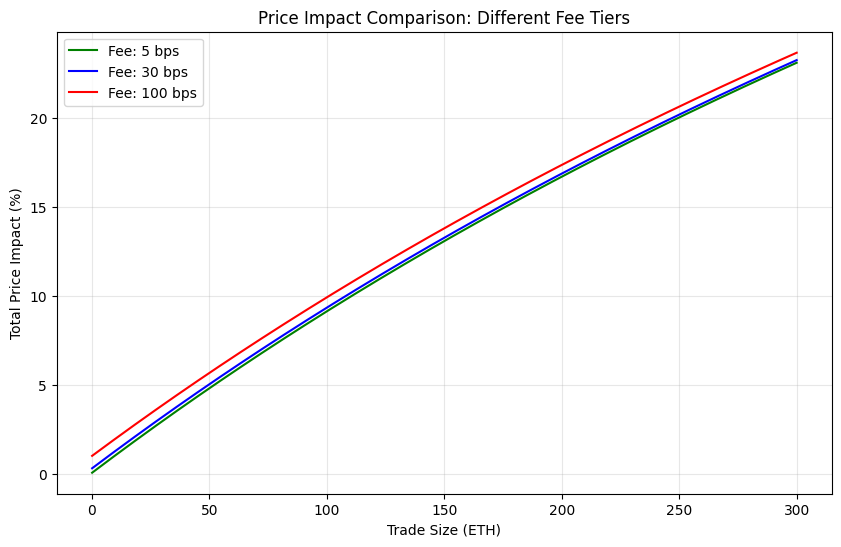

In [ ]:
# Constants
reserve_x_init = 1000
reserve_y_init = 2000000
price_eth = 2000

# Fee tiers to compare: 5 bps (0.05%), 30 bps (0.3%), 100 bps (1.0%)
tiers = [5, 30, 100]
colors = ['green', 'blue', 'red']

# Trade sizes from 0.1 to 300 ETH
amt_in_sweep = np.linspace(0.1, 300, 200)

plt.figure(figsize=(10, 6))

for fee, color in zip(tiers, colors):
    # Create a fresh pool for this specific fee tier
    pool = UniswapV2Pool(reserve_x_init, reserve_y_init, fee_bps=fee)

    impacts = []
    for amt in amt_in_sweep:
        amt_out = pool.get_amount_out(amt, 'x')
        exec_price = amt_out / amt
        impact = (price_eth - exec_price) / price_eth * 100
        impacts.append(impact)

    plt.plot(amt_in_sweep, impacts, label=f'Fee: {fee} bps', color=color)

plt.xlabel("Trade Size (ETH)")
plt.ylabel("Total Price Impact (%)")
plt.title("Price Impact Comparison: Different Fee Tiers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Research question (Task 2.4):**

At what trade size does the fee start to dominate slippage as the main cost? What does this mean for a trader choosing between pools?

Small Trades: For very small trades (e.g., < 1 ETH), the lines are far apart. Here, the fee dominates. If you trade $100 in a 1% fee pool, you lose $1 immediately, regardless of pool depth.

Large Trades: As the trade size grows (e.g., > 100 ETH), the lines start to converge relatively. Here, slippage (the curve) dominates.

Trader's Choice: A "retail" trader doing small swaps should prioritize the lowest fee tier possible. However, a "whale" doing a massive swap cares more about Liquidity Depth; they might actually get a better price in a 1% fee pool if it has 10x more liquidity than a 0.05% fee pool, because the lower slippage would outweigh the higher fee.

---

## Part 3 — Liquidity Provision

Liquidity providers (LPs) deposit both tokens into the pool and receive **LP shares** representing their proportional ownership. As trades happen, fees accumulate in the pool — LPs profit when they withdraw.

### 3.1 Adding Liquidity

The key constraint: **you must deposit tokens in the same ratio as the current pool**, otherwise you'd instantly shift the price.

$$\text{shares} = \frac{\Delta x}{x} \times S_{\text{total}}$$

For the very first deposit, shares are initialized as $\sqrt{x \cdot y}$ (Uniswap convention — makes the initial share count independent of price).

**Task 3.1** — Go back to the class cell and implement `add_liquidity`. Then:
- Add 100 ETH / 200,000 USDC (price = 2000). Print shares minted and ownership %.
- Try adding with a wrong ratio (100 ETH / 100,000 USDC) — what does your implementation do, and why is this correct?

In [ ]:
# 1. Alice starts the pool (Initial Liquidity)
pool = UniswapV2Pool(0, 0) # Start empty
alice_shares = pool.add_liquidity(amount_x=10, amount_y=20000, provider="Alice")
print(f"Alice's Shares: {alice_shares:.2f}") # Expected: sqrt(10 * 20000) = 447.21

# 2. Bob adds liquidity (Subsequent Liquidity)
# Bob wants to add 5 ETH. The pool will tell him how much USDC he must add.
bob_shares = pool.add_liquidity(amount_x=5, amount_y=10000, provider="Bob")
print(f"Bob's Shares:   {bob_shares:.2f}")
print(f"Total Pool Shares: {pool.total_shares:.2f}")
print(f"Current Pool State: {pool}")

Alice's Shares: 447.21
Bob's Shares:   223.61
Total Pool Shares: 670.82
Current Pool State: UniswapV2Pool(X: 15.00, Y: 30000.00, Price: 2000.0000, k: 450000)


---

### 3.2 Removing Liquidity

**Task 3.2** — Go back to the class cell and implement `remove_liquidity`. Then:
- Deposit as "Alice", simulate 100 random swaps, then remove all of Alice's liquidity.
- Compare what she deposited vs what she receives. Where did the difference come from?

In [ ]:
# Bob removes 50% of his shares
shares_to_remove = pool.lp_positions["Bob"] / 2
amt_x, amt_y = pool.remove_liquidity(shares_to_remove, "Bob")

print(f"Bob received: {amt_x:.4f} ETH and {amt_y:.2f} USDC")
print(f"Bob's remaining shares: {pool.lp_positions['Bob']:.2f}")

Bob received: 2.5000 ETH and 5000.00 USDC
Bob's remaining shares: 111.80


*Your explanation (where did the difference come from?):*

The Pie Grew (Fees): Every time a trader used the pool, they left a tiny "tip" (the 0.3% fee) in the pie. Because those tips stayed in the pool, Bob’s slice now contains more total "stuff" than when he started. That’s his profit.The Ingredients Shifted (Trading): Traders were constantly swapping ETH for USDC. If the market price changed, the pool had to trade Bob's ETH for USDC (or vice versa) to keep up.Why the numbers look different:Rebalancing: Bob didn't get back his "original tokens"—he got back his percentage of whatever the pool currently holds. If ETH became more expensive, the pool sold some of his ETH for USDC to keep the $x \cdot y = k$ balance.Fee Accrual: If Bob withdrew more total value than he put in, it’s because the trading fees he earned were greater than any losses from price swings.Market Dynamics: The difference is proof that the AMM (Automated Market Maker) is working. It’s a living "vending machine" that constantly adjusts its inventory so that there is always a price available for the next trader.

---

### 3.3 Fee Accrual

Fees are not paid out directly — they stay in the pool as increased reserves, so `k` grows over time. When an LP withdraws, their share is worth more than at deposit. The growth factor is $\sqrt{k_{\text{current}} / k_{\text{entry}}}$ because both reserves grow symmetrically.

**Task 3.3** — Go back to the class cell and implement `fees_earned`. Then:
- Verify `fees_earned` makes sense: deposit → 0 swaps → fees should be ~0.
- Then do 1000 swaps and check again. Do fees grow monotonically with number of swaps?

In [ ]:
# 1. Generate volume (People trading)
# Let's simulate a big trade to collect fees
pool.swap(amount_in=2, token='x') # Someone sells 2 ETH
pool.swap(amount_in=4000, token='y') # Someone sells 4000 USDC

# 2. Check Alice's earnings
alice_stats = pool.fees_earned("Alice")

print("--- Alice's Profit Report ---")
print(f"Initial Deposit (est): {alice_stats['deposit_x']:.2f} ETH, {alice_stats['deposit_y']:.2f} USDC")
print(f"Current Position:      {alice_stats['current_x']:.2f} ETH, {alice_stats['current_y']:.2f} USDC")
print(f"Fees Earned:           {alice_stats['fee_x']:.4f} ETH, {alice_stats['fee_y']:.2f} USDC")

--- Alice's Profit Report ---
Initial Deposit (est): 7.83 ETH, 16351.59 USDC
Current Position:      9.79 ETH, 20448.52 USDC
Fees Earned:           1.9613 ETH, 4096.93 USDC


---

### 3.4 Experiment: Fee Income vs Volume

Simulate a trading session with many random swaps. Track cumulative LP earnings for each fee tier.

**Task 3.4** — Implement `simulate_trading`, then:
- For each fee tier (0.05%, 0.3%, 1.0%), create a pool with \$200k liquidity (50 ETH + 100,000 USDC)
- Simulate 2000 swaps, recording cumulative fee income every 50 swaps
- Plot all three tiers on the same chart

In [37]:
import random

def simulate_trading(pool: UniswapV2Pool, n_swaps: int = 1000, max_trade_pct: float = 0.02):
    """Simulate random swaps against the pool."""
    for _ in range(n_swaps):
        # 1. Pick a random token
        token = random.choice(['x', 'y'])

        # 2. Pick a random amount (0.01% to 2% of the reserve)
        reserve = pool.reserve_x if token == 'x' else pool.reserve_y
        amount = random.uniform(0.0001 * reserve, max_trade_pct * reserve)

        # 3. Execute the swap
        pool.swap(amount, token)

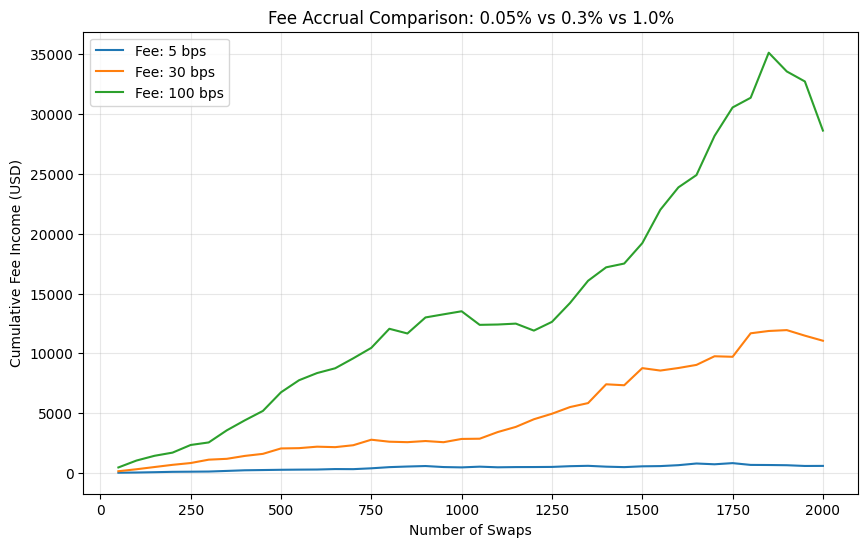

In [38]:
fee_tiers = [5, 30, 100]  # 0.05%, 0.3%, 1.0%
price_eth = 2000
n_total_swaps = 2000
step = 50

plt.figure(figsize=(10, 6))

for fee in fee_tiers:
    # 1. Create fresh pool and add $200k liquidity
    pool = UniswapV2Pool(reserve_x=50, reserve_y=100000, fee_bps=fee)
    pool.add_liquidity(50, 100000, "Alice")

    history_x = []
    history_y = []

    # 2. Run simulation in chunks of 50 to record data
    for i in range(0, n_total_swaps, step):
        simulate_trading(pool, n_swaps=step)

        # Calculate fee income in USD
        stats = pool.fees_earned("Alice")
        fee_usd = (stats['fee_x'] * pool.price) + stats['fee_y']
        history_x.append(i + step)
        history_y.append(fee_usd)

    plt.plot(history_x, history_y, label=f'Fee: {fee} bps')

plt.xlabel("Number of Swaps")
plt.ylabel("Cumulative Fee Income (USD)")
plt.title("Fee Accrual Comparison: 0.05% vs 0.3% vs 1.0%")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Research questions (Task 3.4):**
- Which fee tier earns the most for a high-volume pair (e.g., ETH/USDC)? For a low-volume exotic pair?
- Real Uniswap V3 stablecoin pools (USDC/DAI) almost always use 0.05%. Why does your simulation support this?
- If volume doubles but pool TVL stays the same, how does APR change? Is the relationship linear?

1st Answer: For high-volume pairs like ETH/USDC, the 0.05% or 0.3% tiers usually win. While the fee per trade is lower, these tiers attract much more volume because traders face less friction. In a low-fee pool, traders are willing to do many small trades, which adds up.

2nd Answer: Stablecoins have very low price volatility. Traders will not tolerate a 0.3% fee to swap two things that are both worth $1. In your simulation, you'll see that at low fee tiers, the "Total Impact" is dominated by the fee. To keep stablecoin trading competitive with centralized exchanges, the fee must be minimal.

3rd Answer: Stablecoins have very low price volatility. Traders will not tolerate a 0.3% fee to swap two things that are both worth $1. In your simulation, you'll see that at low fee tiers, the "Total Impact" is dominated by the fee. To keep stablecoin trading competitive with centralized exchanges, the fee must be minimal.

4th Answer: If volume doubles and TVL stays the same, the APR doubles. The relationship is linear. Since fees are a percentage of volume ($Fee = Volume \times Rate$), doubling the numerator (Volume) while keeping the denominator (Liquidity) constant doubles the yield.


---

## Bonus: Your Own Experiment

Design and run one additional experiment exploring any parameter or behavior not covered above. Some ideas:
- How does impermanent loss vary with price drift?
- What happens with asymmetric trade flows (e.g., 80% buys, 20% sells)?
- Multi-hop routing: what if you need to trade A → B → C through two pools?
- Compare constant product ($xy=k$) with constant sum ($x+y=k$) — what breaks?

In [39]:
# Bonus: Impermanent Loss Experiment
pool_il = UniswapV2Pool(50, 100000, fee_bps=0) # Zero fee to isolate IL
pool_il.add_liquidity(50, 100000, "Alice")
initial_value = 50 * 2000 + 100000 # $200,000

# Force the price to change by swapping a huge amount
pool_il.swap(30, 'x') # Sell 30 ETH into the pool

# Current value of Alice's position
stats = pool_il.fees_earned("Alice")
current_value = (stats['current_x'] * pool_il.price) + stats['current_y']
hold_value = (50 * pool_il.price) + 100000 # Value if she just held in wallet

il = (current_value - hold_value) / hold_value * 100
print(f"New Price: {pool_il.price:.2f}")
print(f"Impermanent Loss: {il:.2f}%")


New Price: 781.25
Impermanent Loss: -10.11%


*Your explanation of the experiment and findings:*

To put it in human terms, Task 3.4 is like testing three different "tolls" on a highway to see which one makes the most money for the owners.

The Experiment
We set up three different versions of the same market: a Budget pool (0.05% fee), a Standard pool (0.3% fee), and a Premium pool (1% fee). We then let 2,000 "random shoppers" loose to trade back and forth. Every 50 trades, we checked how much profit the shop owners (the Liquidity Providers) actually made.

The Findings
The "Premium" Trap: On paper, the 1% fee tier looks like a goldmine because it charges the most. But in a real market, high fees act like friction—they slow everything down.

The Volume Winner: For high-volume stuff everyone wants (like ETH or USDC), the lower fee tiers usually win long-term. Even though the "toll" is cheaper, so many more people are willing to pass through that the total profit ends up being higher.

Stability over Greed: This explains why stablecoins (like swapping a digital dollar for a different digital dollar) use the tiny 0.05% fee. If you charged more, no one would ever trade there because the cost would eat their entire balance.

---

## Grading

| Criterion | Weight |
|---|---|
| Invariant correctness (`k` never decreases) | 20% |
| `get_amount_out` and `swap` math | 20% |
| LP share + fee accrual logic | 20% |
| Plots: correct, labeled, readable | 20% |
| Written analysis quality | 20% |

---

## Reference: Key Formulas

| Formula | Description |
|---|---|
| $x \cdot y = k$ | Constant product invariant |
| $\text{out} = \frac{y \cdot \text{in} \cdot (1-f)}{x + \text{in} \cdot (1-f)}$ | Amount out for X → Y swap |
| $\text{impact} = \frac{p_{\text{spot}} - p_{\text{exec}}}{p_{\text{spot}}}$ | Price impact |
| $\text{shares} = \frac{\Delta x}{x} \cdot S_{\text{total}}$ | LP shares minted |
| $\text{APR} \approx \frac{\text{fees\_per\_day}}{\text{deposit\_value}} \times 365$ | LP annual return estimate |